# Yield Curve Module 3
***IRRBB -- OIS Curve Application***

---
<span style="color:gray; font-size:0.85em">

Note on **banking capital requirements** regulatory stack: 

BCBS → CRR/CRD (EU law) → EBA RTS/GL (technical detail) → ECB/NCAs (supervision)

- **BCBS**: global blueprint, no legal force
- **CRR/CRD**: EU law, co-legislated by Parliament and Council on Commission proposal
    - CRR: a regulation, directly applicable in all member states
    - CRD: a directive, requires each member state, by a given deadline, to transpose it into national law, allowing some flexibily.
- **EBA**
    - RTS: *Regulatory Technical Standards* (substance) **binding**
    - ITS: *Implementing Technical Standards* (format/template/procedures) **binding**
    - GL: *Guidelines* comply-or-explain for national supervisors
- **ECB/NCAs**: enforce, supervise, set Pillar 2 (P2R and P2G based on SREP)

#### EBA/GL/2022/14 (governance)

* scope: IRRBB and CSRBB definition and perimeter
* governance: board oversight, internal limits, risk appetite
* behavioural assumptions: NMD modelling, loan prepayments
* stress testing: internal scenarios, model validation
* CSRBB: identification, measurement, monitoring

#### EBA/RTS/2022/09 (quantitative)

* 6 prescribed shock scenarios (parallel, twist, short up/dn, long up/dn, steepener)
* EVE outlier test: threshold 15% of Tier 1
* NII outlier test: threshold 5% of Tier 1 NII
* exact SOT (supervisory outlier test) calculation methodology
* reporting format to supervisors

#### Topics organized in Basel Pillars

**Pillar 1** -- minimum capital · CRR3

- credit risk RWA (SA, IRB, output floor)
- market risk RWA (FRTB)
- operational risk RWA (SMA)
- liquidity (LCR, NSFR)
- leverage ratio

**Pillar 2** -- supervisory review · CRD VI

- SREP and Pillar 2 capital add-ons (P2R, P2G)
- IRRBB · EBA/GL/2022/14 + EBA/RTS/2022/09
- CSRBB · EBA/GL/2022/14
- governance, remuneration, fit and proper
- capital buffers (CCyB, G-SII, O-SII)

**Pillar 3** -- disclosure · CRR3 Part Eight

- public risk and capital disclosures
- EBA ITS on disclosure formats

**Resolution** -- outside Basel pillars

- BRRD2 (recovery and resolution planning)
- MREL (SRB binding decisions)
- TLAC (CRR2, G-SIBs only)
- DGSD (deposit guarantee)

#### Acronyms

**Regulatory framework**

- BCBS: Basel Committee on Banking Supervision
- CRR: Capital Requirements Regulation
- CRD: Capital Requirements Directive
- BRRD: Bank Recovery and Resolution Directive
- DGSD: Deposit Guarantee Schemes Directive

**EU agencies and authorities**

- EBA: European Banking Authority
- ECB: European Central Bank
- SSM: Single Supervisory Mechanism
- SRB: Single Resolution Board
- NCA: National Competent Authority
- SRF: Single Resolution Fund

**Capital and RWA**

- RWA: Risk-Weighted Assets
- CET1: Common Equity Tier 1
- SA: Standardised Approach (regulator-prescribed risk weights based on external ratings and asset class)
- IRB: Internal Ratings-Based (bank uses its own models for PD, LGD, EAD)
- SMA: Standardised Measurement Approach (applies to operational risk)
- TLAC: Total Loss Absorbing Capacity
- MREL: Minimum Requirement for own funds and Eligible Liabilities
- CCyB: Countercyclical Capital Buffer
- G-SII: Global Systemically Important Institution
- O-SII: Other Systemically Important Institution

**Market and liquidity risk**

- FRTB: Fundamental Review of the Trading Book
- SA: Standardised Approach (sensitivity-based, standardised risk weights applied to Greeks)
- IMA: bank uses its own expected shortfall model, requires:
    - desk-level supervisor approval
    - passing P&L attribution test
    - backtesting
- LCR: Liquidity Coverage Ratio
- NSFR: **Net Stable Funding Ratio**
- HQLA: High Quality Liquid Assets

**Interest rate and credit risk**

- IRRBB: Interest Rate Risk in the Banking Book
- CSRBB: Credit Spread Risk in the Banking Book
- SREP: **Supervisory Review and Evaluation Process**
- SOT: **Supervisory Outlier Test**
- EVE: **Economic Value of Equity**
- NII: **Net Interest Income**
- NMD: Non-Maturity Deposit
- ECL: Expected Credit Loss
- PD: Probability of Default
- LGD: Loss Given Default
- EAD: Exposure at Default
</span>


#### EBA/RTS/2022/10 Annex I -- Prescribed IRRBB Shock Sizes (bps)
<span style="color:gray; font-size:0.85em">

Source: EBA/RTS/2022/10, Annex I, October 2022.
These are regulatory inputs.
<small>

 Currency | Parallel | Short | Long 
----------|----------|-------|------
 EUR      | 200      | 250   | 100  
 USD      | 200      | 300   | 150  
 JPY      | 100      | 100   | 100  
 BRL      | 400      | 500   | 300  
 GBP      | 250      | 300   | 150  
 CHF      | 100      | 150   | 100  

 </small>


<b>EBA Methodology:</b> To arrive in these values, EBA calibrated shocks to the 99th percentile of rolling 6-month interest rate changes over 2000-2015. A floor of 100bps applies to all currencies regardless of historical data. 

<b>BRL note:</b> BRL is not an EBA-regulated currency -- it is included in the Basel BCBS standard which uses the same methodology. A Luxembourg bank with material BRL positions would apply these shocks under Pillar 2 ICAAP at its own discretion, not as a mandatory EBA SOT.

<b>JPY note:</b> The 100bps flat shock across all tenors reflects the prolonged near-zero rate environment in Japan. Post-2022 BoJ policy normalisation has reopened debate on whether this remains appropriate. The BCBS recalibration exercise (d561, 2023) flagged this as a currency where
the current shocks may need upward revision.

**How the six scenarios are derived from these three shock sizes:**

Let $S_{parallel}$, $S_{short}$, $S_{long}$ denote the prescribed shock sizes
from the table above for a given currency. Then:

$$\Delta R_{parallel} = \pm S_{parallel}$$

$$\Delta R_{steepener} = -0.65 \cdot S_{short} + 0.9 \cdot S_{long}$$

$$\Delta R_{flattener} = +0.8 \cdot S_{short} - 0.6 \cdot S_{long}$$

$$\Delta R_{short\_up} = +S_{short} \text{ (fading linearly to zero at 20Y+)}$$

$$\Delta R_{short\_down} = -S_{short} \text{ (fading linearly to zero at 20Y+)}$$

#### Post-Shock Interest Rate Floor

EBA/RTS/2022/10 Article 4 imposes a maturity-dependent lower bound on
post-shock rates:

$$floor(T) = -150\text{bps} + 3\text{bps} \cdot T$$

The floor reflects the empirical lower bound on nominal interest rates;
the effective lower bound (ELB) below which monetary transmission breaks
down and cash hoarding becomes rational. 

The slope of 3bps per year embeds the term premium; longer maturities
can sustain slightly less negative rates because the compensation for
duration risk provides a natural floor. At key maturities:

<small>

| Maturity | Floor |
|----------|-------|
| 0Y       | -150bps |
| 10Y      | -120bps |
| 20Y      | -90bps  |
| 30Y      | -60bps  |

</small>
For EUR the floor is rarely binding post-2022 given the ECB has exited
negative rate territory and current short rates sit above 1.5%. For JPY
the floor is material, with the BoJ only beginning normalisation in
2024, a -100bps parallel down shock on a curve starting near zero
immediately breaches the floor across the short and medium end.

The floor also has a practical implication for EVE: when the floor clips
a downward scenario, the actual EVE impact is smaller than the unclipped
version. The EBA requires institutions to report both the clipped
(regulatory) and unclipped (unconstrained) parallel down scenario
precisely to make this effect transparent to supervisors.

#### Data

OIS zero curve bootstrapped in Notebook 2, loaded from `data/processed/`.
All EVE calculations use OIS discounting as prescribed by EBA/RTS/2022/09.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

from quant_risk.curves.ois import OISCurve

# -----------------------------------------------------------------------
# load OIS curve built and saved by notebook 02_bootstrapping_ois.ipynb
# -----------------------------------------------------------------------
ois_curve      = OISCurve.from_processed()
ois_data       = ois_curve._ois_data        # DataFrame for downstream cells
valuation_date = ois_curve.valuation_date

print(ois_curve.describe())
print(f"\n{ois_data[['years', 'zero_rate_pct']].round(4)}")

OISCurve | currency=EUR | valuation_date=2026-05-05

            years  zero_rate_pct
maturity                        
1M         0.0833         1.9396
2M         0.1667         1.9756
3M         0.2500         2.0645
6M         0.5000         2.2194
9M         0.7500         2.3935
12M        1.0000         2.3688
2Y         2.0000         2.4608
3Y         3.0000         2.5038
5Y         5.0000         2.5592
10Y       10.0000         2.8345
10Y+      15.0000         3.0127


In [2]:
# EBA/RTS/2022/10 Annex I -- prescribed shock sizes in bps by currency
EBA_SHOCKS = {
    "EUR": {"parallel": 200, "short": 250, "long": 100},
    "USD": {"parallel": 200, "short": 300, "long": 150},
    "JPY": {"parallel": 100, "short": 100, "long": 100},
    "BRL": {"parallel": 400, "short": 500, "long": 300},
    "GBP": {"parallel": 250, "short": 300, "long": 150},
    "CHF": {"parallel": 100, "short": 150, "long": 100},
}

# EBA prescribed 19 maturity buckets -- defined here so midpoints
# can be added to T before scenario computation
EBA_BUCKETS = {
    "ON"        : (0,        1/365),
    ">1D-1M"    : (1/365,    1/12),
    ">1M-3M"    : (1/12,     3/12),
    ">3M-6M"    : (3/12,     6/12),
    ">6M-9M"    : (6/12,     9/12),
    ">9M-1Y"    : (9/12,     1.0),
    ">1Y-1.5Y"  : (1.0,      1.5),
    ">1.5Y-2Y"  : (1.5,      2.0),
    ">2Y-3Y"    : (2.0,      3.0),
    ">3Y-4Y"    : (3.0,      4.0),
    ">4Y-5Y"    : (4.0,      5.0),
    ">5Y-6Y"    : (5.0,      6.0),
    ">6Y-7Y"    : (6.0,      7.0),
    ">7Y-8Y"    : (7.0,      8.0),
    ">8Y-9Y"    : (8.0,      9.0),
    ">9Y-10Y"   : (9.0,      10.0),
    ">10Y-15Y"  : (10.0,     15.0),
    ">15Y-20Y"  : (15.0,     20.0),
    ">20Y"      : (20.0,     50.0),
}

def compute_bucket_midpoints(buckets):
    midpoints = {label: (low + high) / 2 for label, (low, high) in buckets.items()}
    midpoints[">20Y"] = 25.0
    return midpoints

def compute_irrbb_scenarios(zero_rates, maturities, currency="EUR"):
    """
    Apply EBA/RTS/2022/10 six IRRBB shock scenarios to a zero rate curve.

    Shock sizes from Annex I. Steepener/flattener formulas from Table 1.
    Short rate shocks fade linearly to zero at 20Y.
    Post-shock floor applied per Article 4: -150bps + 3bps per year.
    """
    s = EBA_SHOCKS[currency]
    S_par   = s["parallel"] / 100
    S_short = s["short"]   / 100
    S_long  = s["long"]    / 100

    w = np.clip(maturities / 20, 0, 1)

    shock_parallel = S_par * np.ones_like(maturities)
    shock_short    = S_short * (1 - w)
    shock_long     = S_long  * w

    floor = (-150 + 3 * maturities) / 100

    raw = {
        "parallel_up"   :  zero_rates + shock_parallel,
        "parallel_down" :  zero_rates - shock_parallel,
        "steepener"     :  zero_rates - 0.65 * shock_short + 0.9 * shock_long,
        "flattener"     :  zero_rates + 0.8  * shock_short - 0.6 * shock_long,
        "short_up"      :  zero_rates + shock_short,
        "short_down"    :  zero_rates - shock_short,
    }

    return {name: np.maximum(curve, floor) for name, curve in raw.items()}

# -----------------------------------------------------------------------
# T: fine plotting grid union exact EBA bucket midpoints
# This ensures scenarios are computed at exactly the right maturities
# for EVE -- no interpolation needed in the EVE cell
# -----------------------------------------------------------------------
midpoints = compute_bucket_midpoints(EBA_BUCKETS)

T_plot = np.linspace(1/12, 30, 360)
T      = np.sort(np.unique(np.concatenate([list(midpoints.values()), T_plot])))

# index of each midpoint in T -- exact, no floating point ambiguity
T_to_idx = {t: int(np.searchsorted(T, t)) for t in midpoints.values()}

baseline  = np.array([ois_curve.zero_rate(t) for t in T])
scenarios = compute_irrbb_scenarios(baseline, T, currency="EUR")

print(f"Baseline curve: OIS -- valuation date {valuation_date}")
print(f"T grid: {len(T)} points from {T[0]:.4f}Y to {T[-1]:.0f}Y "
      f"(includes {len(midpoints)} EBA midpoints)")
print(f"\n{'Scenario':<20} {'ON rate':>10} {'3M rate':>10} {'10Y rate':>10} {'30Y rate':>10}")
print("-" * 65)
for name, curve in [("Baseline", baseline)] + list(scenarios.items()):
    on_idx = T_to_idx[midpoints["ON"]]
    print(f"{name:<20} "
          f"{curve[on_idx]:>10.3f} "
          f"{curve[T_to_idx[midpoints['>1M-3M']]]:>10.3f} "
          f"{curve[T_to_idx[midpoints['>9Y-10Y']]]:>10.3f} "
          f"{curve[-1]:>10.3f}")

Baseline curve: OIS -- valuation date 2026-05-05
T grid: 373 points from 0.0014Y to 30Y (includes 19 EBA midpoints)

Scenario                ON rate    3M rate   10Y rate   30Y rate
-----------------------------------------------------------------
Baseline                  1.936      1.967      2.792      3.230
parallel_up               3.936      3.967      4.792      5.230
parallel_down            -0.064     -0.033      0.792      1.230
steepener                 0.311      0.363      2.367      4.130
flattener                 3.936      3.946      3.557      2.630
short_up                  4.436      4.447      4.105      3.230
short_down               -0.564     -0.512      1.480      3.230


In [3]:
# check if floor is binding for any EUR scenario
floor = (-150 + 3 * T) / 100

print("Floor binding check -- EUR scenarios:")
for name, curve in scenarios.items():
    n_clipped = np.sum(curve < floor + 1e-6)
    min_rate  = curve.min()
    if n_clipped > 0:
        print(f"  {name:<20} min rate: {min_rate:.3f}%   floor binding at {n_clipped} points")
    else:
        print(f"  {name:<20} min rate: {min_rate:.3f}%   floor not binding")

Floor binding check -- EUR scenarios:
  parallel_up          min rate: 3.936%   floor not binding
  parallel_down        min rate: -0.064%   floor not binding
  steepener            min rate: 0.311%   floor not binding
  flattener            min rate: 2.523%   floor not binding
  short_up             min rate: 3.123%   floor not binding
  short_down           min rate: -0.564%   floor not binding


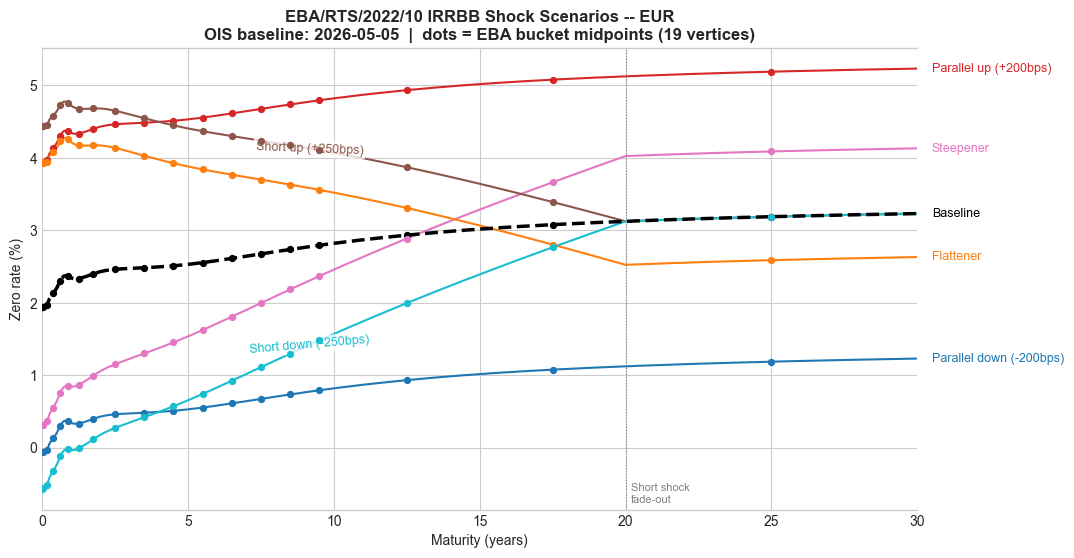

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.set_xlim(0, 30)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

colors = {
    "parallel_up"   : "#d62728",
    "parallel_down" : "#1f77b4",
    "steepener"     : "#e377c2",
    "flattener"     : "#ff7f0e",
    "short_up"      : "#8c564b",
    "short_down"    : "#17becf",
}

end_labels = {
    "parallel_up"   : ("Parallel up (+200bps)",  0.0),
    "parallel_down" : ("Parallel down (-200bps)", 0.0),
    "steepener"     : ("Steepener",               0.0),
    "flattener"     : ("Flattener",               0.0),
}

mid_labels = {
    "short_up"   : ("Short up (+250bps)",   120),
    "short_down" : ("Short down (-250bps)", 120),
}

def line_angle_correct(curve, ax):
    x_data_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_data_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    bbox = ax.get_window_extent()
    x_pixel_range = bbox.width
    y_pixel_range = bbox.height
    x1, x2 = T[50], T[200]
    y1, y2 = curve[50], curve[200]
    data_slope = (y2 - y1) / (x2 - x1)
    display_slope = data_slope * (x_pixel_range / x_data_range) / (y_pixel_range / y_data_range)
    return np.degrees(np.arctan(display_slope))

# EBA midpoint x-positions and T indices
mp_x = [T_i for T_i in midpoints.values()]

# baseline
ax.plot(T, baseline, color="black", linewidth=2.5, linestyle="--", zorder=5)
ax.text(30.5, baseline[-1], "Baseline", color="black", fontsize=9,
        va="center", clip_on=False)
ax.scatter(mp_x, [baseline[T_to_idx[T_i]] for T_i in midpoints.values()],
           s=18, color="black", zorder=6, marker="o")

# scenario curves with midpoint markers
for name, curve in scenarios.items():
    ax.plot(T, curve, color=colors[name], linewidth=1.5)
    ax.scatter(mp_x, [curve[T_to_idx[T_i]] for T_i in midpoints.values()],
               s=18, color=colors[name], zorder=6, marker="o")

    if name in end_labels:
        label, offset = end_labels[name]
        ax.text(30.5, curve[-1] + offset, label,
                color=colors[name], fontsize=9, va="center", clip_on=False)

fig.canvas.draw()

for name, (label, idx) in mid_labels.items():
    curve = scenarios[name]
    angle = line_angle_correct(curve, ax)
    ax.text(T[idx], curve[idx], label,
            color=colors[name], fontsize=9,
            va="center", ha="center",
            rotation=angle,
            rotation_mode="anchor",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))

ax.axvline(x=20, color="grey", linewidth=0.8, linestyle=":")
ax.text(20.2, ax.get_ylim()[0] + 0.1, "Short shock\nfade-out",
        color="grey", fontsize=8)

ax.set_title(
    f"EBA/RTS/2022/10 IRRBB Shock Scenarios -- EUR\n"
    f"OIS baseline: {valuation_date}  |  dots = EBA bucket midpoints (19 vertices)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Zero rate (%)")
ax.set_xlabel("Maturity (years)")
fig.subplots_adjust(right=0.75)
plt.show()

## 2. EVE Impact Table
**IRRBB Supervisory Outlier Test**

Economic Value of Equity (EVE) is the present value of interest-rate sensitive
assets minus interest-rate sensitive liabilities, covering instruments with
contractual cash flows (loans, bonds, deposits, derivatives). It excludes
equities, non-financial assets (property, equipment), and own funds instruments
(CET1, AT1, and typically Tier 2) whose exclusion is a regulatory convention
to avoid circularity with the Tier 1 SOT denominator.

$$EVE = PV(assets_\text{IR-sensitive}) - PV(liabilities_\text{IR-sensitive})$$

When rates shift, both sides reprice and the net change is $\Delta EVE$.
For a single cash flow of notional $N$ at maturity $T$:

$$\Delta EVE(s, T) = N \cdot \left[ P_s(0, T) - P_{base}(0, T) \right]$$

where $P_s(0,T) = e^{-r_s(T) \cdot T / 100}$ uses the shocked zero rate.

The EBA supervisory outlier test (SOT) flags a bank as an outlier if:

$$\frac{|\Delta EVE|}{Tier 1 \, capital} > 15\%$$

Tier 1 capital (CET1 + AT1) is the regulatory measure of core loss-absorbing
capacity. It enters only as the normalisation reference: the buffer against
which interest rate risk is sized.

### Sensitivity analysis 

We show below how 1mm notional would resposnd to shocks for different maturities. Notice these key properties:

- $\Delta EVE$ scales linearly with notional, results below are per EUR 1M
- $\Delta EVE$ is larger in absolute terms for longer maturities, duration effect
- The post-shock floor (eventually) clips downward scenarios, reducing $|\Delta EVE|$ for
  parallel down and short down scenarios where post-shock rates would otherwise
  breach the ELB
- A bank with a structural long position in fixed rate assets will show
  negative $\Delta EVE$ under parallel up, the classic banking book mismatch
  the IRRBB framework is designed to capture

<center>

SOT threshold: $\dfrac{|\Delta EVE|}{Tier 1} > 15\%$ triggers supervisory review and potential P2R add-on

</center>

Baseline discount curve: ESTR OIS bootstrapped in Notebook 2, loaded
from `data/processed/`. Shocked discount factors are derived by applying
the EBA shocks to the OIS zero rates and recomputing $P_s(0,T) = e^{-r_s(T) \cdot T/100}$.

<span style="color:gray; font-size:0.85em">
Own funds instruments (CET1, AT1, and typically Tier 2) are excluded from
the liability side as these are loss-absorbing regulatory capital instruments:

- CET1: ordinary shares and retained earnings, the highest quality capital
- AT1: perpetual instruments (typically CoCos) with discretionary coupons,
  convertible to equity or written down when CET1 falls below a trigger
- Tier 2: subordinated debt with fixed maturity and coupon, ranks below
  senior creditors in insolvency, gone-concern loss absorption

The EBA treatment under EBA/GL/2022/14 allows some discretion on Tier 2, but most banks exclude it for consistency, documenting the choice as part of their IRRBB governance framework.


In [5]:
# EVE impact table -- per EUR 1M notional at each pillar maturity
# Delta EVE = N * (P_shocked - P_baseline)

N = 1_000_000  # EUR 1M notional

records = []
for label, row_data in ois_data.iterrows():
    T_i    = row_data["years"]
    r_base = row_data["zero_rate_pct"]
    df_base = np.exp(-r_base / 100 * T_i)

    row = {
        "maturity"    : label,
        "zero_rate_%"  : round(r_base, 4),
        "df_baseline"  : round(df_base, 6),
    }

    # delta EVE under each scenario
    for name, curve in scenarios.items():
        r_shocked  = np.interp(T_i, T, curve)
        df_shocked = np.exp(-r_shocked / 100 * T_i)
        delta_eve  = (df_shocked - df_base) * N
        row[name]  = round(delta_eve, 2)

    records.append(row)

eve_table = pd.DataFrame(records).set_index("maturity")

In [6]:
# color negative values red, positive green
def color_delta(val):
    if isinstance(val, float):
        color = "#d62728" if val < 0 else "#2ca02c"
        return f"color: {color}"
    return ""

tbl = eve_table.drop(columns=["df_baseline"]).style\
.format({
    "zero_rate_%"   : "{:.4f}%",
    "parallel_up"   : "{:,.0f}",
    "parallel_down" : "{:,.0f}",
    "steepener"     : "{:,.0f}",
    "flattener"     : "{:,.0f}",
    "short_up"      : "{:,.0f}",
    "short_down"    : "{:,.0f}",
})
scenario_cols = ["parallel_up", "parallel_down",
    "steepener", "flattener",
    "short_up", "short_down"]

tbl.map(color_delta, subset=
scenario_cols)\
.set_caption(
    f"ΔEVE per EUR 1M notional -- EBA/RTS/2022/10 scenarios -- {valuation_date}"
)


,zero_rate_%,parallel_up,parallel_down,steepener,flattener,short_up,short_down
maturity,,,,,,,
1M,1.9396%,"-1,661","1,667","1,346","-1,652","-2,068","2,075"
2M,1.9756%,"-3,303","3,342","2,682","-3,267","-4,096","4,141"
3M,2.0645%,"-4,942","5,006","3,991","-4,862","-6,102","6,179"
6M,2.2194%,"-9,759","10,022","7,836","-9,440","-11,898","12,210"
9M,2.3935%,"-14,453","15,019","11,513","-13,745","-17,397","18,062"
12M,2.3688%,"-19,070","20,007","15,024","-17,824","-22,654","23,752"
2Y,2.4608%,"-36,749","39,478","27,113","-31,977","-41,313","44,448"
3Y,2.5038%,"-53,219","58,266","36,223","-42,929","-56,492","61,970"
5Y,2.5592%,"-82,533","94,004","46,217","-56,193","-77,534","87,936"


## 3. NII Supervisory Outlier Test

Net Interest Income (NII) measures the difference between interest earned
on assets and interest paid on liabilities over a defined horizon -- here
one year, as prescribed by EBA/RTS/2022/10.

$$NII = \sum_i r_i^{assets} \cdot N_i^{assets} - \sum_j r_j^{liabilities} \cdot N_j^{liabilities}$$

The NII SOT flags an outlier if:

$$\frac{|\Delta NII|}{Tier 1 \, capital} > 5\%$$

Where $\Delta NII = NII_{shocked} - NII_{baseline}$ under parallel up or
parallel down scenarios over a one-year horizon.

Only two scenarios apply to the NII SOT -- parallel up and parallel down.
The other four scenarios (steepener, flattener, short up, short down) are
EVE-only.

**Stylised banking book for illustration:**

A simplified balance sheet used to demonstrate the NII calculation. In a production system the cash flow engine provides actual contractual and behavioural cash flows per instrument.

The bond and loan **rates** are fixed at inception, they do not reprice when rates move (see note 2).
The deposit liabilities reprice immediately (wholesale) or with a behavioural lag (retail NMDs modelled as 2Y average repricing).


<small>
<b>Note 1:</b> do not confuse <b>repricing</b> and <b>revaluation</b>. When we say loans and bonds do not reprice, we mean their contractual rate was fixed at origination and does not change
when market rates move. This is what drives NII sensitivity: a fixed rate asset
generates the same cash flows regardless of where rates go. However its present value
does change when discount rates move, and this is what drives EVE sensitivity.

<b>Note 2:</b> For the sake of populating the asset table we are taking NSS_AAA curve + spread, but notice this is just a convenience to chose a static rate on this exercise. 



## Mock example: SOT for IRRBB
**supervisory outlier tests: NII and EVE**

### A. balance sheet

In [7]:
from quant_risk.curves.nss import NSSCurve

# convenient rates used to populate the mock banking book positions
nss_aaa = NSSCurve.from_ecb(rating="AAA", date=valuation_date)

r_aaa_3y  = nss_aaa.zero_rate(3.0)
r_aaa_5y  = nss_aaa.zero_rate(5.0)
r_aaa_10y = nss_aaa.zero_rate(10.0)
r_ois_1m  = ois_curve.zero_rate(1/12)
r_ois_2y  = ois_curve.zero_rate(2.0)

In [8]:
# -----------------------------------------------------------------------
# banking book -- positions defined with monthly tenors
# -----------------------------------------------------------------------

# total assets = total liabilities + tier 1 capital

tier1_capital = 300  # EUR M

credit_spread_corp  = 2.50   # 250bps on corporate loans
credit_spread_mort  = 1.50   # 150bps on mortgages over 5Y AAA
nmd_spread          = 0.50   # NMDs pay ESTR - 50bps # behavioural spread over 1M OIS

book = {
    "gov_bond_portfolio": {
        "type"            : "asset",
        "notional"        : 400,
        "maturity_months" : 120,           # 10Y AAA government bonds
        "coupon_months"   : 12,
        "rate"            : r_aaa_10y,
        "floating"        : False,
    },
    "corp_bond_portfolio": {
        "type"            : "asset",
        "notional"        : 200,
        "maturity_months" : 60,            # 5Y corporate bonds
        "coupon_months"   : 12,
        "rate"            : r_aaa_5y + credit_spread_corp,
        "floating"        : False,
    },
    "mortgage_book": {
        "type"            : "asset",
        "notional"        : 500,
        "maturity_months" : 240,           # 20Y fixed rate mortgages
        "coupon_months"   : 12,
        "rate"            : r_aaa_5y + credit_spread_mort,
        "floating"        : False,
    },
    "corporate_loans": {
        "type"            : "asset",
        "notional"        : 300,
        "maturity_months" : 36,            # 3Y floating rate loans
        "coupon_months"   : 3,
        "rate"            : r_ois_1m + credit_spread_corp,
        "floating"        : True,
    },
    "wholesale_deposits": {
        "type"            : "liability",
        "notional"        : 500,
        "maturity_months" : 1,             # overnight
        "coupon_months"   : 1,
        "rate"            : r_ois_1m,
        "floating"        : True,
    },
    "term_deposits_3m": {
        "type"            : "liability",
        "notional"        : 200,
        "maturity_months" : 3,             # 3M term deposits
        "coupon_months"   : 3,
        "rate"            : r_ois_1m + 0.10,  # slight premium over overnight
        "floating"        : True,
    },
    "term_deposits_1y": {
        "type"            : "liability",
        "notional"        : 200,
        "maturity_months" : 12,            # 1Y term deposits
        "coupon_months"   : 12,
        "rate"            : r_ois_2y,      # 1Y rate
        "floating"        : False,
    },
    "retail_nmd": {
        "type"            : "liability",
        "notional"        : 200,
        "maturity_months" : 24,            # behavioural 2Y
        "coupon_months"   : 12,
        "rate"            : max(0, r_ois_1m - nmd_spread),
        "floating"        : True,
    },
}

In [9]:
# verify balance sheet
total_assets = sum(p["notional"] for p in book.values() if p["type"] == "asset")
total_liabs  = sum(p["notional"] for p in book.values() if p["type"] == "liability")
equity       = total_assets - total_liabs

print(f"Total assets      : EUR {total_assets}M")
print(f"Total liabilities : EUR {total_liabs}M")
print(f"Implied equity    : EUR {equity}M")
print(f"Tier 1 capital    : EUR {tier1_capital}M")
print(f"Balance check     : {'OK' if equity == tier1_capital else f'MISMATCH by {equity - tier1_capital}M'}")

print(f"\n{'Position':<25} {'Type':<12} {'Notional':>10} {'Maturity':>10} {'Rate':>8} {'Floating':>10}")
print("-" * 80)
for name, pos in book.items():
    print(f"{name:<25} {pos['type']:<12} {pos['notional']:>8}M "
          f"{pos['maturity_months']:>8}M {pos['rate']:>8.4f}% "
          f"{'Yes' if pos['floating'] else 'No':>10}")

Total assets      : EUR 1400M
Total liabilities : EUR 1100M
Implied equity    : EUR 300M
Tier 1 capital    : EUR 300M
Balance check     : OK

Position                  Type           Notional   Maturity     Rate   Floating
--------------------------------------------------------------------------------
gov_bond_portfolio        asset             400M      120M   3.1255%         No
corp_bond_portfolio       asset             200M       60M   5.2565%         No
mortgage_book             asset             500M      240M   4.2565%         No
corporate_loans           asset             300M       36M   4.4379%        Yes
wholesale_deposits        liability         500M        1M   1.9379%        Yes
term_deposits_3m          liability         200M        3M   2.0379%        Yes
term_deposits_1y          liability         200M       12M   2.4292%         No
retail_nmd                liability         200M       24M   1.4379%        Yes


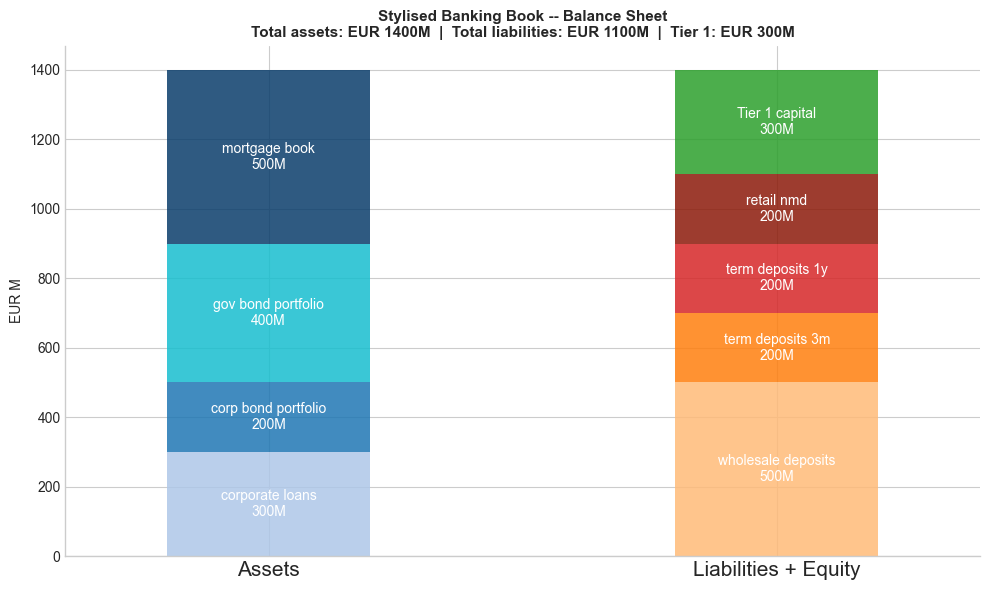

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# -----------------------------------------------------------------------
# stacked balance sheet -- assets left, liabilities + equity right
# assets: most liquid at top, least liquid at bottom
# liabilities: most short term at top, least short term at bottom
# -----------------------------------------------------------------------

# order assets most liquid to least liquid (top to bottom = stack bottom to top)
asset_order = [
    "corporate_loans",
    "corp_bond_portfolio",
    "gov_bond_portfolio",
    "mortgage_book",
]

# order liabilities most short term to least short term
liab_order = [
    "wholesale_deposits",
    "term_deposits_3m",
    "term_deposits_1y",
    "retail_nmd",
]

asset_colors = ["#aec7e8", "#1f77b4", "#17becf", "#0a3d6b"]
liab_colors  = ["#ffbb78", "#ff7f0e", "#d62728", "#8c1a0a"]
equity_color = "#2ca02c"

# plot assets -- stacked horizontal bars on left side (negative x)
bottom = 0
for i, name in enumerate(asset_order):
    val = book[name]["notional"]
    ax.bar(0, val, bottom=bottom, width=0.4,
           color=asset_colors[i], alpha=0.85,
           label=name.replace("_", " "))
    ax.text(0, bottom + val/2,
            f"{name.replace('_', ' ')}\n{val}M",
            ha="center", va="center", fontsize=10,
            color="white", fontweight="500")
    bottom += val

# plot liabilities -- stacked on right
bottom = 0
for i, name in enumerate(liab_order):
    val = book[name]["notional"]
    ax.bar(1, val, bottom=bottom, width=0.4,
           color=liab_colors[i], alpha=0.85)
    ax.text(1, bottom + val/2,
            f"{name.replace('_', ' ')}\n{val}M",
            ha="center", va="center", fontsize=10,
            color="white", fontweight="500")
    bottom += val

# plot equity on top of liabilities
ax.bar(1, tier1_capital, bottom=bottom, width=0.4,
       color=equity_color, alpha=0.85)
ax.text(1, bottom + tier1_capital/2,
        f"Tier 1 capital\n{tier1_capital}M",
        ha="center", va="center", fontsize=10,
        color="white", fontweight="500")

# formatting
total_assets = sum(book[k]["notional"] for k in asset_order)
total_liabs  = sum(book[k]["notional"] for k in liab_order)

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(0, max(total_assets, total_liabs + tier1_capital) * 1.05)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Assets", "Liabilities + Equity"], fontsize=15)
ax.set_ylabel("EUR M")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title(
    f"Stylised Banking Book -- Balance Sheet\n"
    f"Total assets: EUR {total_assets}M  |  "
    f"Total liabilities: EUR {total_liabs}M  |  "
    f"Tier 1: EUR {tier1_capital}M",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

### B. SOT NII

**SOT NII: Net Interest Income Supervisory Outlier Test**


Computed for two scenarios only:

- parallel up
- parallel down

The shock size is currency-dependent. For EUR the prescribed shock is $\pm 200$ bps.
The SOT flags a bank as an outlier if:

$$\frac{|\Delta NII|}{Tier 1} > 5\%$$

where $|\Delta NII|$ is the larger of the two parallel scenarios.

In [11]:
# -----------------------------------------------------------------------
# NII computation -- forward rates from shocked OIS curve
# -----------------------------------------------------------------------

def compute_nii_position(
    notional, 
    maturity_months, 
    coupon_months,
    is_floating, 
    position_type,
    fixed_rate_pct,
    shocked_zero_rates, 
    shocked_maturities,
    horizon_months=12, # nii over a 1 year horizon by default
    ):
    """
    Compute NII contribution of a SINGLE POSITION over the NII horizon.

    Fixed rate positions: earn/pay their fixed rate on coupon payment dates
    within the horizon. Principal cash flows beyond the horizon are excluded.

    Floating rate positions: reprice at each rollover date using the forward
    rate implied by the shocked OIS curve for that period.

    Parameters
    ----------
    notional : float
        Position notional in EUR M.
    maturity_months : int
        Instrument tenor in months.
    coupon_months : int
        Coupon/interest payment frequency in months.
    is_floating : bool
        True if position reprices at rollover.
    position_type : str
        'asset' or 'liability'.
    fixed_rate_pct : float
        Fixed coupon rate in percent. Used only if is_floating=False.
    shocked_zero_rates : np.ndarray
        Shocked zero rates in percent on fine maturity grid.
    shocked_maturities : np.ndarray
        Corresponding maturities in years.
    horizon_months : int
        NII projection horizon in months.

    Returns
    -------
    float
        NII contribution in EUR M.
    """
    nii = 0.0

    def df_shocked(t_years):
        """Shocked discount factor at maturity t_years."""
        if t_years <= 0:
            return 1.0
        # interpolate shocked zero rate 
        zr = np.interp(t_years, shocked_maturities, shocked_zero_rates)
        # convert to discount factor
        return np.exp(-zr / 100 * t_years)

    def fwd_rate_pct(t_start_years, t_end_years):
        """
        Annualised forward rate between t_start and t_end
        discrete time compounding
        from the shocked OIS curve, in percent.
        """
        period = t_end_years - t_start_years
        if period <= 0:
            return 0.0
        df_s = df_shocked(t_start_years)
        df_e = df_shocked(t_end_years)
        return (df_s / df_e - 1) / period * 100

    if not is_floating:
        # fixed rate -- earns fixed_rate_pct on each coupon date within horizon
        coupon_dates = np.arange(coupon_months, horizon_months + 1, coupon_months)
        for t_months in coupon_dates:
            if t_months > maturity_months:
                break
            period = coupon_months / 12
            interest = notional * fixed_rate_pct / 100 * period
            nii += interest if position_type == "asset" else -interest

    else:
        # floating -- reprices at each rollover within horizon
        # constant balance sheet: maturing notional is rolled into
        # new instrument at the forward rate for that period
        reprice_dates = np.arange(0, horizon_months, maturity_months)

        for t_start_months in reprice_dates:
            t_start = t_start_months / 12
            t_end   = min((t_start_months + maturity_months) / 12,
                          horizon_months / 12)
            period  = t_end - t_start

            if period <= 0:
                break

            rate = fwd_rate_pct(t_start, t_end)
            interest = notional * rate / 100 * period
            nii += interest if position_type == "asset" else -interest

    return nii


def compute_book_nii(
    book, 
    shocked_zero_rates, 
    shocked_maturities,
    horizon_months=12,
    ):
    """
    Compute total NII for the full banking book.

    Returns total NII and per-position breakdown in EUR M.
    """
    total_nii  = 0.0
    breakdown  = {}

    for name, pos in book.items():
        nii = compute_nii_position(
            notional           = pos["notional"],
            maturity_months    = pos["maturity_months"],
            coupon_months      = pos["coupon_months"],
            is_floating        = pos["floating"],
            position_type      = pos["type"],
            fixed_rate_pct     = pos["rate"],
            shocked_zero_rates = shocked_zero_rates,
            shocked_maturities = shocked_maturities,
            horizon_months     = horizon_months,
        )
        breakdown[name] = round(nii, 4)
        total_nii += nii

    return round(total_nii, 4), breakdown


# -----------------------------------------------------------------------
# compute baseline and shocked NII
# -----------------------------------------------------------------------
nii_base,  breakdown_base  = compute_book_nii(book, baseline, T)
nii_up,    breakdown_up    = compute_book_nii(book, scenarios["parallel_up"], T)
nii_down,  breakdown_down  = compute_book_nii(book, scenarios["parallel_down"], T)

delta_nii_up   = nii_up   - nii_base
delta_nii_down = nii_down - nii_base

# supervisory outilier test -- delta NII as % of tier 1 capital
sot_up   = abs(delta_nii_up)   / tier1_capital * 100
sot_down = abs(delta_nii_down) / tier1_capital * 100

# -----------------------------------------------------------------------
# results table
# -----------------------------------------------------------------------
print(f"\nNII SOT -- 1 year horizon -- OIS forward rates per repricing date")
print(f"Valuation date: {valuation_date}")
print(f"\n{'Position':<25} {'Baseline':>12} {'Par up':>12} {'Par down':>12}")
print("-" * 65)
for name in book:
    print(f"{name:<25} {breakdown_base[name]:>12.4f} "
          f"{breakdown_up[name]:>12.4f} {breakdown_down[name]:>12.4f}")
print("-" * 65)
print(f"{'Total NII (EUR M)':25} {nii_base:>12.4f} "
      f"{nii_up:>12.4f} {nii_down:>12.4f}")
print(f"\n{'Delta NII (EUR M)':25} {'--':>12} "
      f"{delta_nii_up:>12.4f} {delta_nii_down:>12.4f}")
print(f"{'Delta NII / Tier 1 (%)':25} {'--':>12} "
      f"{sot_up:>12.2f} {sot_down:>12.2f}")
print(f"{'SOT breach (>5%)':25} {'--':>12} "
      f"{'YES' if sot_up > 5 else 'NO':>12} "
      f"{'YES' if sot_down > 5 else 'NO':>12}")


NII SOT -- 1 year horizon -- OIS forward rates per repricing date
Valuation date: 2026-05-05

Position                      Baseline       Par up     Par down
-----------------------------------------------------------------
gov_bond_portfolio             12.5020      12.5020      12.5020
corp_bond_portfolio            10.5129      10.5129      10.5129
mortgage_book                  21.2823      21.2823      21.2823
corporate_loans                 7.1051      13.3090       1.0240
wholesale_deposits            -11.7153     -21.7432      -1.7042
term_deposits_3m               -4.6954      -8.7289      -0.6819
term_deposits_1y               -4.8583      -4.8583      -4.8583
retail_nmd                     -4.7367      -8.8727      -0.6827
-----------------------------------------------------------------
Total NII (EUR M)              25.3965      13.4031      37.3941

Delta NII (EUR M)                   --     -11.9934      11.9976
Delta NII / Tier 1 (%)              --         4.00      

In [12]:
print("\nPer-position NII breakdown -- parallel up:")
print(f"  {'Position':<25} {'Baseline':>10} {'Shocked':>10} {'Delta':>10}")
print("-" * 58)
for name in book:
    print(f"  {name:<25} {breakdown_base[name]:>10.4f} "
          f"{breakdown_up[name]:>10.4f} "
          f"{breakdown_up[name] - breakdown_base[name]:>10.4f}")


Per-position NII breakdown -- parallel up:
  Position                    Baseline    Shocked      Delta
----------------------------------------------------------
  gov_bond_portfolio           12.5020    12.5020     0.0000
  corp_bond_portfolio          10.5129    10.5129     0.0000
  mortgage_book                21.2823    21.2823     0.0000
  corporate_loans               7.1051    13.3090     6.2039
  wholesale_deposits          -11.7153   -21.7432   -10.0279
  term_deposits_3m             -4.6954    -8.7289    -4.0335
  term_deposits_1y             -4.8583    -4.8583     0.0000
  retail_nmd                   -4.7367    -8.8727    -4.1360


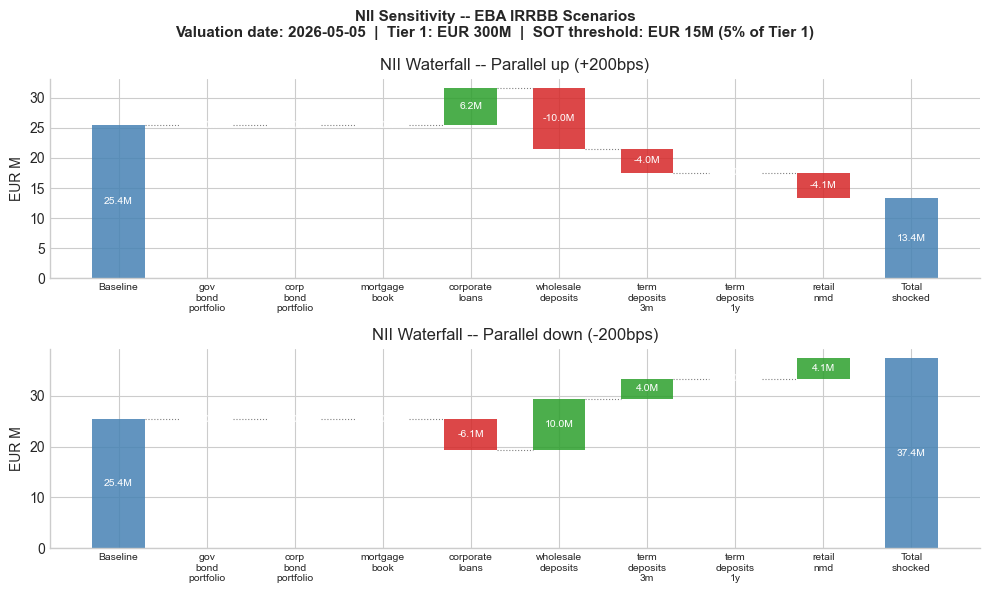

In [13]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6))

def waterfall(ax, breakdown_base, breakdown_shocked, title, shock_label):
    """
    Waterfall chart showing NII baseline and delta contribution per position.
    """
    positions  = list(breakdown_base.keys())
    labels     = ["Baseline"] + [p.replace("_", "\n") for p in positions] + ["Total\nshocked"]

    # compute deltas
    deltas = {p: breakdown_shocked[p] - breakdown_base[p] for p in positions}
    total_base    = sum(breakdown_base.values())
    total_shocked = sum(breakdown_shocked.values())

    # running total for waterfall
    values  = [total_base] + [deltas[p] for p in positions] + [total_shocked]
    bottoms = []
    running = total_base

    # baseline bar starts at 0
    bottoms.append(0)

    # delta bars start at running total
    for p in positions:
        d = deltas[p]
        if d >= 0:
            bottoms.append(running)
        else:
            bottoms.append(running + d)
        running += d

    # final bar starts at 0
    bottoms.append(0)

    # colors
    colors = []
    colors.append("steelblue")  # baseline
    for p in positions:
        colors.append("#2ca02c" if deltas[p] >= 0 else "#d62728")
    colors.append("steelblue" if total_shocked >= 0 else "#d62728")  # total

    bars = ax.bar(range(len(labels)), [abs(v) for v in values],
                  bottom=bottoms, color=colors, alpha=0.85, width=0.6)

    # value labels
    for i, (val, bot) in enumerate(zip(values, bottoms)):
        y = bot + abs(val)/2
        ax.text(i, y, f"{val:.1f}M",
                ha="center", va="center", fontsize=7.5,
                color="white", fontweight="500")

    # connector lines between bars
    running = total_base
    for i, p in enumerate(positions):
        d = deltas[p]
        x_left  = i + 0.3
        x_right = i + 0.7
        y_level = running if d >= 0 else running + d
        ax.plot([x_left, x_right], [running, running],
                color="grey", linewidth=0.8, linestyle=":")
        running += d

    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylabel("EUR M")
    ax.set_title(f"NII Waterfall -- {shock_label}", fontweight="500")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

waterfall(ax0, breakdown_base, breakdown_up,
          "Parallel Up", f"Parallel up (+{EBA_SHOCKS['EUR']['parallel']}bps)")
waterfall(ax1, breakdown_base, breakdown_down,
          "Parallel Down", f"Parallel down (-{EBA_SHOCKS['EUR']['parallel']}bps)")

fig.suptitle(
    f"NII Sensitivity -- EBA IRRBB Scenarios\n"
    f"Valuation date: {valuation_date}  |  Tier 1: EUR {tier1_capital}M  |  "
    f"SOT threshold: EUR {tier1_capital * 0.05:.0f}M (5% of Tier 1)",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

### C. EVE SOT

**EVE SOT: Economic Value of Equity Supervisory Outlier Test**

The EVE SOT measures the change in the economic value of the banking book
under each of the six EBA prescribed rate shock scenarios:

$$EVE = PV(\text{assets}) - PV(\text{liabilities})$$

For each shocked scenario $s$, we compute a $\Delta EVE$:
$$\Delta EVE_s =  EVE_{base} - EVE_{s}$$

Finally, teh test checks for each scenario if there is a breach:
$$\frac{|\Delta EVE_s|}{Tier 1} > 15\%$$

where $s$ runs over the six prescribed scenarios and the present values
are computed using the OIS discount curve shifted by each scenario.

#### IMA vs SA

* IMA: Internal Models Approach
* SA: Standardized Approach

Under IMA, banks compute $\Delta EVE$ position by position using:
- full cash flow schedules
- behavioural assumptions (prepayment models, NMD decay curves)
- optionality pricing

This is what banks use internally for risk management and what sophisticated banks submit as their primary SOT metric.

EBA/RTS/2022/09 requires all banks to **compute and report the SA**, regardless of whether they use IMA. The SA serves as a supervisory benchmark: it allows the supervisor to compare the internal
model output against a standardised calculation and assess whether the IMA is producing materially lower EVE sensitivity. A large divergence between IMA and SA $\Delta EVE$ is itself a supervisory signal. 

#### SA cash flow slotting
EBA/RTS/2022/09 Annex III

The SA approximates $\Delta EVE$ by slotting cash flows into 19 prescribed maturity buckets (overnight to >20Y) and applying a single discount factor per bucket:

$$\Delta EVE_s = \sum_{i=1}^{19} Gap_i \cdot \left[ P_s(0, T_i) - P_{base}(0, T_i) \right]$$

where $Gap_i$ is the net cash flow (assets minus liabilities) repricing
in bucket $i$, and $T_i$ is the **midpoint of bucket $i$**, used as the
representative maturity for discounting. Each position **appears once**, in the **bucket corresponding to its next repricing date**:

- **fixed rate**: next repricing = maturity date
- **floating rate**: next repricing = next reset date

Equity is slotted as a liability in the >20Y bucket, ensuring
$\sum_{i=1}^{19} Gap_i = 0$.

This notebook implements the SA. The repricing gap and cumulative gap are shown as an analytical addendum in section D.

In [14]:
def slot_to_bucket(maturity_years):
    for label, (low, high) in EBA_BUCKETS.items():
        if low <= maturity_years < high:
            return label
    return ">20Y"

# -----------------------------------------------------------------------
# slot all repricing cash flows into buckets
# -----------------------------------------------------------------------
bucket_labels = list(EBA_BUCKETS.keys())
gap = pd.DataFrame(0.0, index=bucket_labels,
                   columns=["assets", "liabilities", "gap"])

for name, pos in book.items():
    t_years  = pos["maturity_months"] / 12
    bucket   = slot_to_bucket(t_years)
    if pos["type"] == "asset":
        gap.loc[bucket, "assets"] += pos["notional"]
    else:
        gap.loc[bucket, "liabilities"] += pos["notional"]

# equity slotted as liability in >20Y per EBA SA
gap.loc[">20Y", "liabilities"] += tier1_capital
gap["gap"]            = gap["assets"] - gap["liabilities"]
gap["cumulative_gap"] = gap["gap"].cumsum()

print(f"Sum of all gaps      : {gap['gap'].sum():.1f}M (should be 0)")
print(f"Final cumulative gap : {gap['cumulative_gap'].iloc[-1]:.1f}M (should be 0)")
print(f"\n{'Bucket':<15} {'Assets':>10} {'Liabilities':>13} {'Gap':>10} {'Cum Gap':>10}")
print("-" * 62)
for label in bucket_labels:
    row = gap.loc[label]
    if row["assets"] != 0 or row["liabilities"] != 0:
        print(f"{label:<15} {row['assets']:>10.1f} {row['liabilities']:>13.1f} "
              f"{row['gap']:>10.1f} {row['cumulative_gap']:>10.1f}")

# -----------------------------------------------------------------------
# EVE SOT -- exact rates at midpoints, direct index into T, no interpolation
# -----------------------------------------------------------------------
df_base = {label: ois_curve.discount(T_i) for label, T_i in midpoints.items()}

df_shocked = {
    s_name: {
        label: np.exp(-s_rates[T_to_idx[T_i]] / 100 * T_i)
        for label, T_i in midpoints.items()
    }
    for s_name, s_rates in scenarios.items()
}

delta_eve = {
    s_name: sum(
        gap.loc[label, "gap"] * (df_shocked[s_name][label] - df_base[label])
        for label in bucket_labels
    )
    for s_name in scenarios
}

worst_case   = max(delta_eve.values(), key=abs)
sot_eve      = abs(worst_case) / tier1_capital * 100
sot_breached = sot_eve > 15

print(f"\nEVE SOT -- valuation date: {valuation_date}")
print(f"\n{'Scenario':<25} {'Delta EVE (EUR M)':>18} {'/ Tier 1 (%)':>14}")
print("-" * 60)
for s_name, deve in delta_eve.items():
    print(f"{s_name:<25} {deve:>18.2f} {abs(deve)/tier1_capital*100:>14.2f}")
print("-" * 60)
print(f"{'Worst case':<25} {worst_case:>18.2f} {sot_eve:>14.2f}")
print(f"{'SOT breach (>15%)':<25} {'YES' if sot_breached else 'NO':>18}")

Sum of all gaps      : 0.0M (should be 0)
Final cumulative gap : 0.0M (should be 0)

Bucket              Assets   Liabilities        Gap    Cum Gap
--------------------------------------------------------------
>1M-3M                 0.0         500.0     -500.0     -500.0
>3M-6M                 0.0         200.0     -200.0     -700.0
>1Y-1.5Y               0.0         200.0     -200.0     -900.0
>2Y-3Y                 0.0         200.0     -200.0    -1100.0
>3Y-4Y               300.0           0.0      300.0     -800.0
>5Y-6Y               200.0           0.0      200.0     -600.0
>10Y-15Y             400.0           0.0      400.0     -200.0
>20Y                 500.0         300.0      200.0        0.0

EVE SOT -- valuation date: 2026-05-05

Scenario                   Delta EVE (EUR M)   / Tier 1 (%)
------------------------------------------------------------
parallel_up                          -113.59          37.86
parallel_down                         162.47          54.16
stee

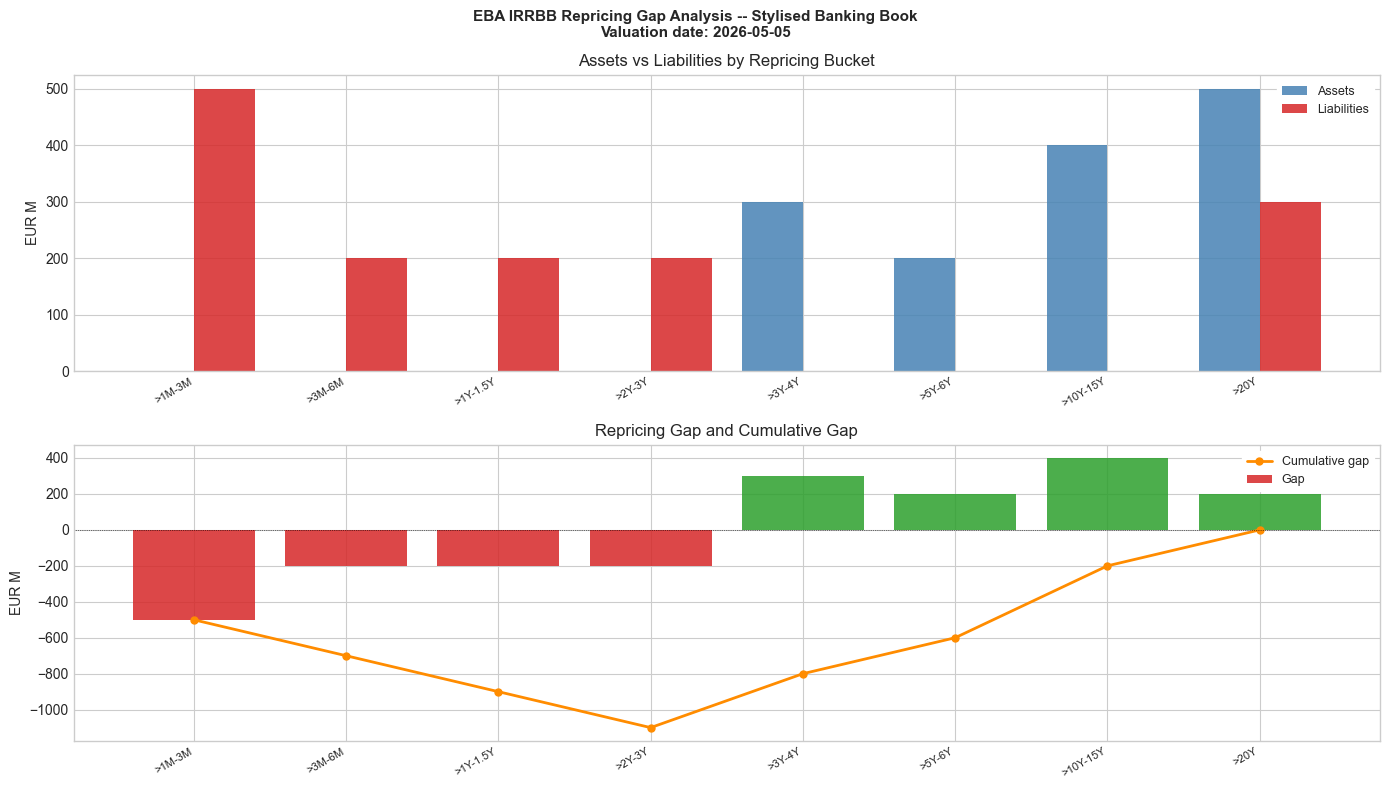

In [15]:
 # -----------------------------------------------------------------------
# plot repricing gap
# -----------------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 8))

# filter only buckets with activity
active = gap[(gap["assets"] != 0) | (gap["liabilities"] != 0)].copy()
x      = np.arange(len(active))

# panel 1 -- assets vs liabilities per bucket
ax0.bar(x - 0.2, active["assets"], width=0.4,
            color="steelblue", alpha=0.85, label="Assets")
ax0.bar(x + 0.2, active["liabilities"], width=0.4,
            color="#d62728", alpha=0.85, label="Liabilities")
ax0.set_xticks(x)
ax0.set_xticklabels(active.index, rotation=30, ha="right", fontsize=8)
ax0.set_ylabel("EUR M")
ax0.set_title("Assets vs Liabilities by Repricing Bucket")
ax0.legend(frameon=True, facecolor="white", framealpha=1,
               edgecolor="white", fontsize=9)
ax0.axhline(0, color="black", linewidth=0.5)

# panel 2 -- gap and cumulative gap
colors_gap = ["#2ca02c" if v >= 0 else "#d62728" for v in active["gap"]]
ax1.bar(x, active["gap"], color=colors_gap, alpha=0.85, label="Gap")
ax1.plot(x, active["cumulative_gap"], color="darkorange",
             linewidth=2, marker="o", markersize=5, label="Cumulative gap")
ax1.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax1.set_xticks(x)
ax1.set_xticklabels(active.index, rotation=30, ha="right", fontsize=8)
ax1.set_ylabel("EUR M")
ax1.set_title("Repricing Gap and Cumulative Gap")
ax1.legend(frameon=True, facecolor="white", framealpha=1,
               edgecolor="white", fontsize=9)

fig.suptitle(
    f"EBA IRRBB Repricing Gap Analysis -- Stylised Banking Book\n"
    f"Valuation date: {valuation_date}",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [17]:
# -----------------------------------------------------------------------
# IRRBB SOT Summary Dashboard
# -----------------------------------------------------------------------
# delta_eve and sot_breached are already computed in the EVE SOT cell
# nii_sot values from the NII cell

worst_eve_scenario = max(delta_eve, key=lambda s: abs(delta_eve[s]))
worst_eve_value    = delta_eve[worst_eve_scenario]
eve_sot_ratio      = abs(worst_eve_value) / tier1_capital * 100
eve_breached       = eve_sot_ratio > 15

nii_sot = {
    "parallel_up"  : delta_nii_up,
    "parallel_down": delta_nii_down,
}
worst_nii_scenario = max(nii_sot, key=lambda s: abs(nii_sot[s]))
worst_nii_value    = nii_sot[worst_nii_scenario]
nii_sot_ratio      = abs(worst_nii_value) / tier1_capital * 100

print("=" * 60)
print("IRRBB SUPERVISORY OUTLIER TEST -- SUMMARY")
print(f"Valuation date : {valuation_date}")
print(f"Tier 1 capital : EUR {tier1_capital}M")
print("=" * 60)

print(f"\nEVE SOT")
print(f"  Reference      : EBA/RTS/2022/10 Article 3")
print(f"  Threshold      : 15% of Tier 1 = EUR {tier1_capital * 0.15:.0f}M")
print(f"  Worst scenario : {worst_eve_scenario.replace('_', ' ').title()}")
print(f"  Delta EVE      : EUR {worst_eve_value:.2f}M")
print(f"  SOT ratio      : {eve_sot_ratio:.2f}%")
print(f"  Result         : {'*** BREACH ***' if eve_breached else 'OK -- within threshold'}")

print(f"\nNII SOT")
print(f"  Reference      : EBA/RTS/2022/10 Article 6")
print(f"  Threshold      : 5% of Tier 1 = EUR {tier1_capital * 0.05:.0f}M")
print(f"  Worst scenario : {worst_nii_scenario.replace('_', ' ').title()}")
print(f"  Delta NII      : EUR {worst_nii_value:.2f}M")
print(f"  SOT ratio      : {nii_sot_ratio:.2f}%")
print(f"  Result         : {'*** BREACH ***' if nii_sot_ratio > 5 else 'OK -- within threshold'}")

print(f"\n{'─' * 60}")
print(f"  All six EVE scenarios:")
for s_name, deve in delta_eve.items():
    flag = " ← breach" if abs(deve)/tier1_capital > 0.15 else ""
    print(f"    {s_name:<20} {deve:>10.2f}M   "
          f"({abs(deve)/tier1_capital*100:.1f}% of Tier 1){flag}")
print(f"{'=' * 60}")

IRRBB SUPERVISORY OUTLIER TEST -- SUMMARY
Valuation date : 2026-05-05
Tier 1 capital : EUR 300M

EVE SOT
  Reference      : EBA/RTS/2022/10 Article 3
  Threshold      : 15% of Tier 1 = EUR 45M
  Worst scenario : Parallel Down
  Delta EVE      : EUR 162.47M
  SOT ratio      : 54.16%
  Result         : *** BREACH ***

NII SOT
  Reference      : EBA/RTS/2022/10 Article 6
  Threshold      : 5% of Tier 1 = EUR 15M
  Worst scenario : Parallel Down
  Delta NII      : EUR 12.00M
  SOT ratio      : 4.00%
  Result         : OK -- within threshold

────────────────────────────────────────────────────────────
  All six EVE scenarios:
    parallel_up             -113.59M   (37.9% of Tier 1) ← breach
    parallel_down            162.47M   (54.2% of Tier 1) ← breach
    steepener                 -5.34M   (1.8% of Tier 1)
    flattener                 -6.43M   (2.1% of Tier 1)
    short_up                 -44.01M   (14.7% of Tier 1)
    short_down                55.84M   (18.6% of Tier 1) ← breach
